In [12]:
import os, sys
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [13]:
script_path = os.getcwd()
project_path = os.path.abspath(os.path.join(script_path, '..', '..', '..'))
results_dir = os.path.join(project_path, 'results', 'experiment_5')
results_path = os.path.join(results_dir, 'master_table_exp_5.parquet')
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
datasets_structure_path = os.path.join(processed_data_dir, 'datasets_structure.parquet') 

sys.path.append(project_path)
from src.utils.experiments_exploration_utils import (
    plot_experiment_5_results, 
    multi_plot_experiment_5_results,
    pareto_plot_experiment_5_results,
    multi_pareto_plot_experiment_5,
    dimensions_plot_experiment_5
)

In [14]:
#######################################################################################################################################################################

SCENARIOS = {
    'simulation_base': 'base',
    'simulation_size_1': 'big_data',
    'simulation_size_2': 'big_data',
    # TODO: add more

}

DIMENSIONS = {
    'size': ['simulation_base', 'simulation_size_1'],
    # TODO: add more
}

DIMENSIONS_METRICS = {
    'size': 'n_rows',
    # TODO: add more
}


datasets_structure = pl.read_parquet(datasets_structure_path)

DIMENSIONS_FORMATTED = {
    k: {data_id: f'{DIMENSIONS_METRICS[k]} {datasets_structure.filter(pl.col('data_id') == data_id)[DIMENSIONS_METRICS[k]][0]}' for data_id in DIMENSIONS[k]}
    for k in DIMENSIONS.keys()
}
#######################################################################################################################################################################

df_results_master = pl.read_parquet(results_path)

df_results_master = df_results_master.with_columns(
    pl.col('data_id').replace(SCENARIOS).alias('scenario')
)

#######################################################################################################################################################################

group_by = {
    'global': ['model_name'],
    'scenario': ['scenario', 'model_name']
}

df_results_master_avg = {}

for k, v in group_by.items():

    df_results_master_avg[k] = df_results_master.group_by(v).agg(
        pl.col('mean_adj_accuracy').mean().alias('mean_adj_accuracy'),
        pl.col('mean_ari').mean().alias('mean_ari'),
        pl.col('mean_time').mean().alias('mean_time'),
        pl.col('std_adj_accuracy').mean().alias('std_adj_accuracy'),
        pl.col('std_ari').mean().alias('std_ari'),
        pl.col('std_time').mean().alias('std_time'),
    ).sort(
        by='mean_adj_accuracy', descending=True, nulls_last=True
    )

#######################################################################################################################################################################

model_names = df_results_master['model_name'].unique().to_list()
our_methods_1 = [x for x in model_names if 'Fast' in x and 'Fold' not in x] # Fast k-medoids
our_methods_2 = [x for x in model_names if 'Fast' in x and 'Fold' in x] # q-Fold Fast k-medoids
other_methods = [x for x in model_names if x not in our_methods_1 + our_methods_2]

#######################################################################################################################################################################

# 1. Filtramos una sola vez todos los registros donde el modelo falló
df_nulls = df_results_master.filter(pl.col('mean_adj_accuracy').is_null())

# --- A NIVEL DE DATASET (data_id) ---
nf_dataset_df = df_nulls.group_by('data_id').agg(pl.col('model_name'))
nf_dataset_dict = dict(zip(nf_dataset_df['data_id'], nf_dataset_df['model_name']))

# Aseguramos que los datasets donde ningún modelo falló tengan una lista vacía
all_data_ids = df_results_master['data_id'].unique().to_list()
not_feasible_methods_dataset = {did: nf_dataset_dict.get(did, []) for did in all_data_ids}


# --- A NIVEL DE ESCENARIO (scenario) ---
# Usamos .unique() para no duplicar nombres si un modelo falla en varios datasets del mismo escenario
nf_scenario_df = df_nulls.group_by('scenario').agg(pl.col('model_name').unique())
nf_scenario_dict = dict(zip(nf_scenario_df['scenario'], nf_scenario_df['model_name']))

all_scenarios = df_results_master['scenario'].unique().to_list()
not_feasible_methods_scenario = {scen: nf_scenario_dict.get(scen, []) for scen in all_scenarios}


# --- A NIVEL GLOBAL ---
# Recuperamos tu lógica del umbral (ej. si falla en más del 30% de los datasets totales)
total_datasets = len(all_data_ids)
global_not_feasible_methods_threshold = 0.3

global_not_feasible_methods = (
    df_nulls.group_by('model_name')
            .agg((pl.len() / total_datasets).alias('prop'))
            .filter(pl.col('prop') >= global_not_feasible_methods_threshold)
)['model_name'].to_list()

#######################################################################################################################################################################

REFERENCE_MODELS = [
    'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming', # TODO: escoger el mejor a nivel global, por dataset, por escenario, por dimensión --> si hay mucha diferencia podría implicar que REFERENCE_MODELS fuese un diccionario en función del nivel analizado
    'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming', # TODO: escoger el mejor a nivel global, por dataset, por escenario, por dimensión --> si hay mucha diferencia podría implicar que REFERENCE_MODELS fuese un diccionario en función del nivel analizado
    'KMeans',
    'MiniBatchKMeans',
    'KMedoids-pam',
    'KMedoids-fastpam',
    'KMedoids-fasterpam',
    'KMedoids-fastermsc',
    'CLARA',
    'GaussianMixture',
    'AgglomerativeClustering',
    'SpectralCoclustering',
    #'SpectralBiclustering',
] # + our_methods_1 + our_methods_2

REFERENCE_MODELS_PALETTE = {
    'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': '#c50f0f', 
    'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': "#c50f0f",      
    'KMeans': '#4949ea',  
    'MiniBatchKMeans': "#4949ea",
    'CLARA': "#3ECB1B", 
    'GaussianMixture': "#d38e25",      
    'AgglomerativeClustering': "#E738D2", 
    'SpectralCoclustering': "#26cce2" ,
    'KMedoids-pam': "#7f29d0",
    'KMedoids-fastpam': "#7f29d0",
    'KMedoids-fasterpam': "#7f29d0",
    'KMedoids-fastermsc': "#7f29d0",  
}

REFERENCE_MODELS_FORMATTED_NAMES = {k: k for k in REFERENCE_MODELS}

REFERENCE_MODELS_FORMATTED_NAMES.update({
    'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fold Fast KMedoids',
    'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fast KMedoids',
})

#######################################################################################################################################################################

In [4]:
df_results_master

model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error,data_id,n_rows,n_cols,n_quant,n_binary,n_multiclass,n_clusters,separation_factor,n_redundant,cluster_proportions,anisotropy_factor,prop_categorical,mean_prop_outliers_quant,mean_prop_outliers_quant_std,outliers_contamination_type,silhouette_index,silhouette_index_std,prop_high_corr_quant,prop_high_corr_quant_std,sphericity_quant,sphericity_quant_std,prop_redundancy_quant,prop_redundancy_quant_std,normalized_balance_entropy,normalized_balance_entropy_std,imbalance_ratio,imbalance_ratio_std,is_balanced,convex_geometry,scenario
str,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,f64,i64,list[f64],f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,str
"""LDAKmeans""",0.975707,0.991565,0.143658,0.037693,0.013565,0.073862,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""AgglomerativeClustering""",0.958265,0.984872,2.042846,0.06321,0.024657,0.133425,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""Birch""",0.95491,0.983702,2.022754,0.065081,0.024804,0.228396,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""KMedoids-fastpam""",0.952461,0.983078,5.407941,0.058846,0.022114,0.75391,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""KMedoids-pam""",0.952461,0.983078,8.351408,0.058846,0.022114,1.638773,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""FastKmedoidsGGower-robust_maha…",0.62631,0.742237,10.513761,0.133022,0.067519,3.904162,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""
"""FastKmedoidsGGower-robust_maha…",0.625449,0.742065,10.512631,0.132632,0.066695,3.821116,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""
"""FastKmedoidsGGower-robust_maha…",0.585553,0.727289,9.847082,0.152168,0.082899,4.14243,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""


In [5]:
df_results_master_avg['global']

model_name,mean_adj_accuracy,mean_ari,mean_time,std_adj_accuracy,std_ari,std_time
str,f64,f64,f64,f64,f64,f64
"""LDAKmeans""",0.931789,0.920349,4.687383,0.032423,0.044,6.217126
"""KMedoids-fastermsc""",0.92761,0.888011,62.874206,0.124439,0.163822,38.341084
"""AgglomerativeClustering""",0.919867,0.902081,20.155993,0.027002,0.057234,7.62186
"""Birch""",0.918641,0.899134,12.8714,0.027098,0.059945,4.741859
"""CLARA""",0.915108,0.873531,0.028689,0.041513,0.084307,0.00872
…,…,…,…,…,…,…
"""FoldFastKmedoidsGGower-robust_…",0.79123,0.604009,4.974409,0.095791,0.172165,1.890517
"""FoldFastKmedoidsGGower-robust_…",0.790518,0.60533,4.996602,0.095955,0.173453,2.067628
"""FastKmedoidsGGower-robust_maha…",0.783692,0.612947,5.798147,0.097505,0.177088,2.160677


In [6]:
df_results_master_avg['scenario']

scenario,model_name,mean_adj_accuracy,mean_ari,mean_time,std_adj_accuracy,std_ari,std_time
str,str,f64,f64,f64,f64,f64,f64
"""base""","""LDAKmeans""",0.991565,0.975707,0.143658,0.013565,0.037693,0.073862
"""base""","""AgglomerativeClustering""",0.984872,0.958265,2.042846,0.024657,0.06321,0.133425
"""base""","""Birch""",0.983702,0.95491,2.022754,0.024804,0.065081,0.228396
"""base""","""KMedoids-fastpam""",0.983078,0.952461,5.407941,0.022114,0.058846,0.75391
"""base""","""KMedoids-pam""",0.983078,0.952461,8.351408,0.022114,0.058846,1.638773
…,…,…,…,…,…,…,…
"""big_data""","""FastKmedoidsGGower-robust_maha…",0.742065,0.625449,10.512631,0.066695,0.132632,3.821116
"""big_data""","""FastKmedoidsGGower-robust_maha…",0.727289,0.585553,9.847082,0.082899,0.152168,4.14243
"""base""","""SpectralBiclustering""",0.725486,0.492743,0.526943,0.199416,0.314596,0.094215


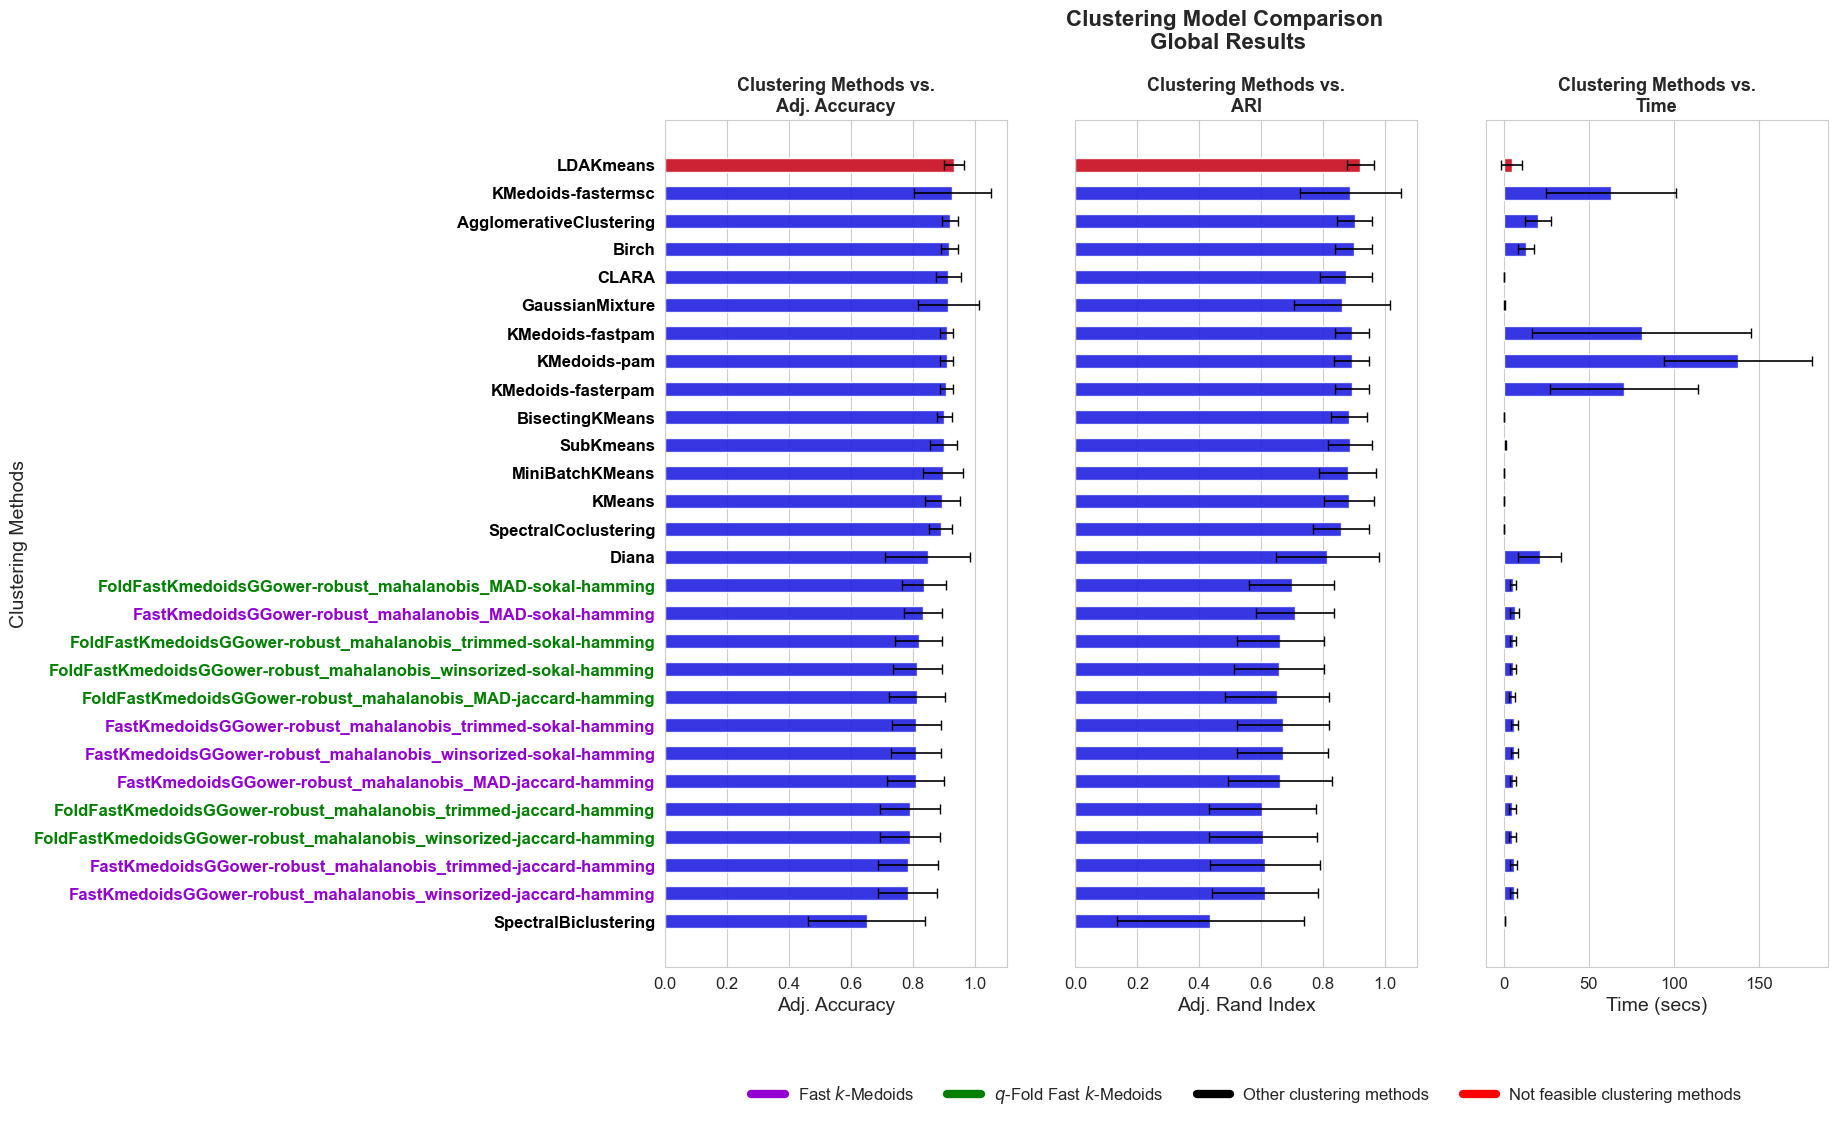

In [7]:
title = f"Clustering Model Comparison \nGlobal Results"

plot_experiment_5_results(
    df_avg=df_results_master_avg['global'], 
    title=title, 
    title_height=0.98,
    time_log_scale=False, 
    save_path=None, 
    our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
    other_methods=other_methods, not_feasible_methods=global_not_feasible_methods
)

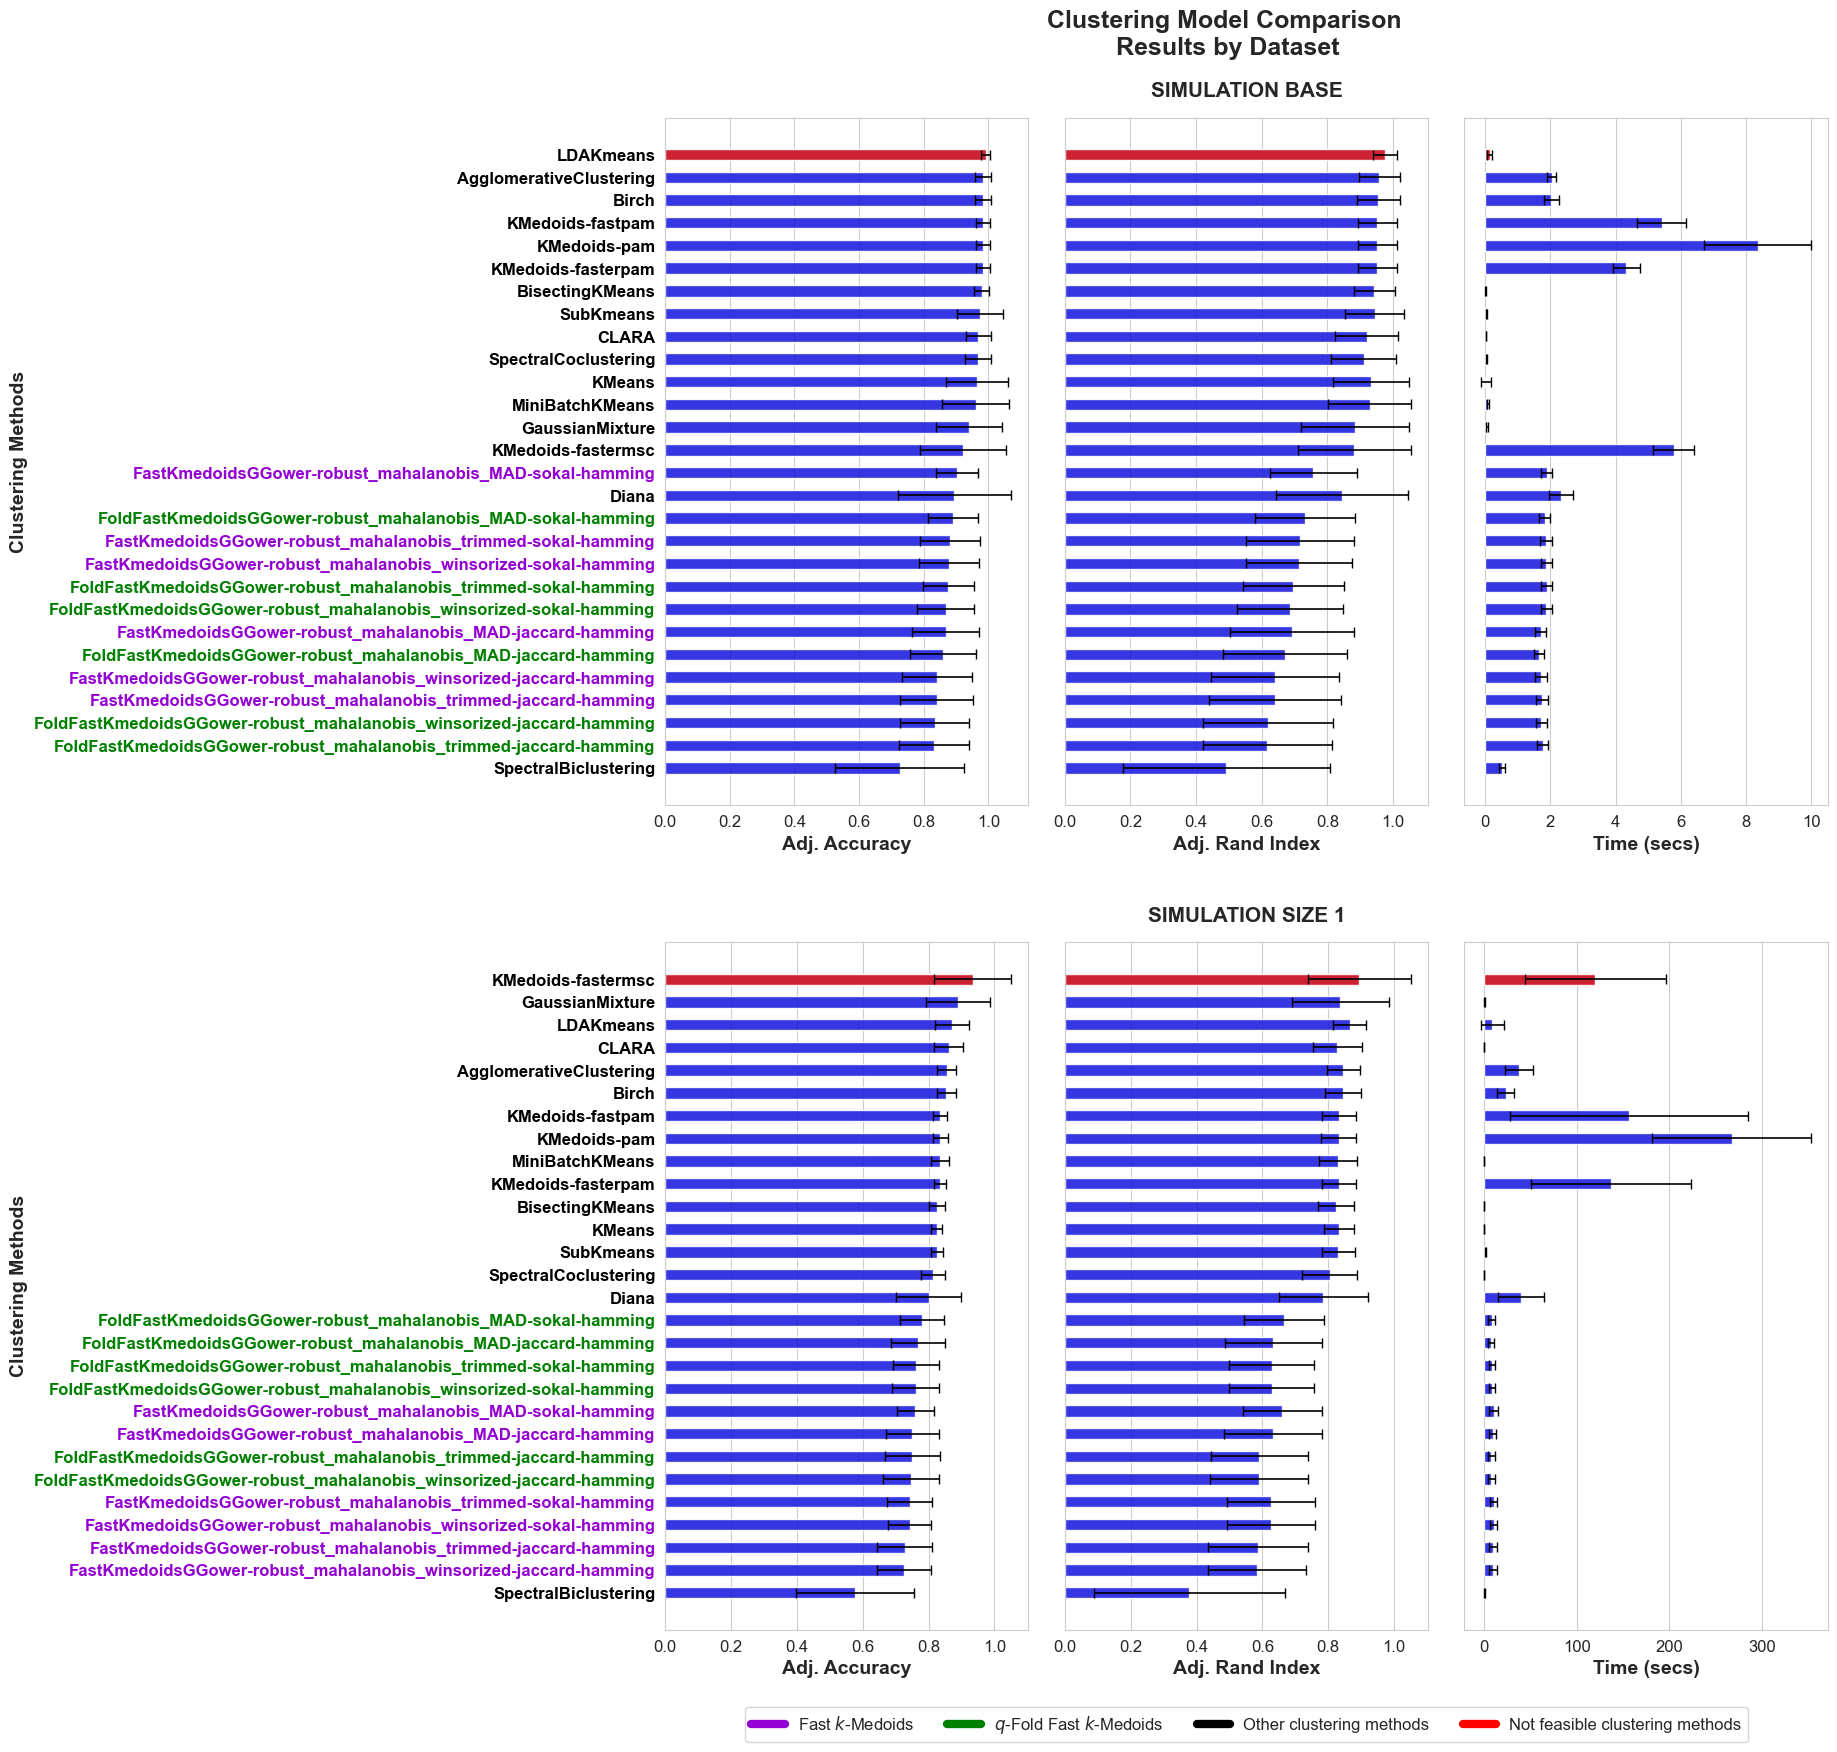

In [8]:
title = f"Clustering Model Comparison \nResults by Dataset"

multi_plot_experiment_5_results(
    df_results_master, 
    subplots_col='data_id',
    subplot_col_target_values=None, 
    title=title, 
    time_log_scale=False, 
    save_path=None, 
    our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
    other_methods=other_methods, not_feasible_methods=not_feasible_methods_dataset,
    hspace=0.2, wspace=0.1,
    fig_height=18, fig_width=15, title_height=0.98
)

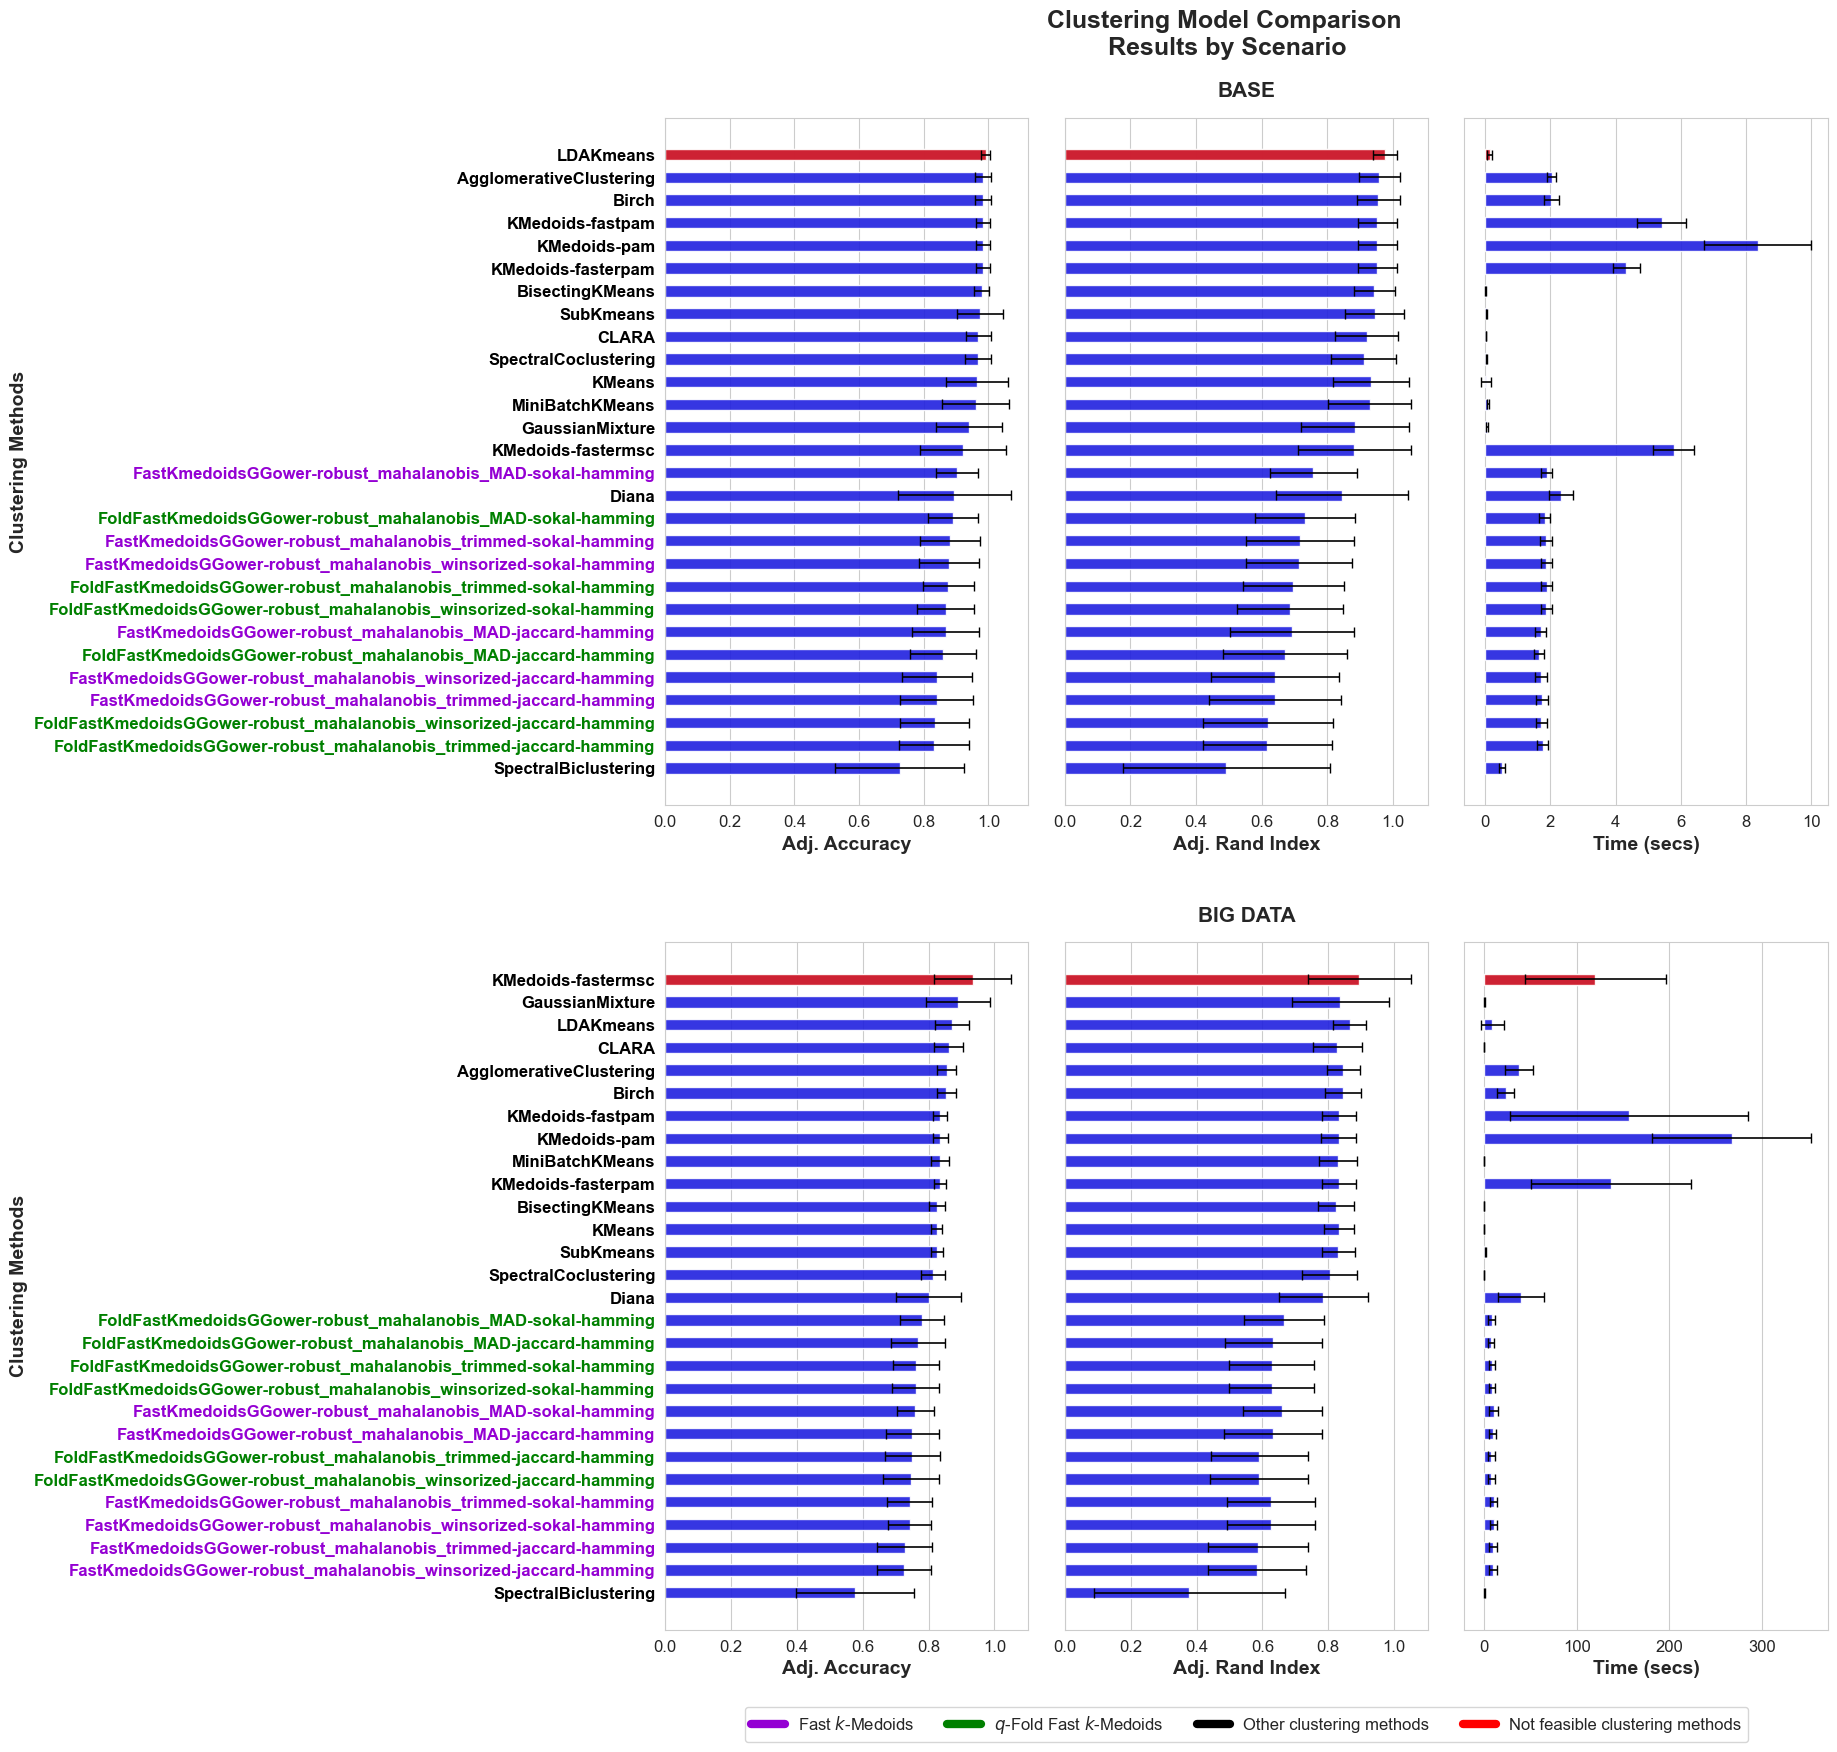

In [9]:
title = f"Clustering Model Comparison \nResults by Scenario"

multi_plot_experiment_5_results(
    df_results_master_avg['scenario'], 
    subplots_col='scenario',
    subplot_col_target_values=None, 
    title=title, 
    time_log_scale=False, 
    save_path=None, 
    our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
    other_methods=other_methods, not_feasible_methods=not_feasible_methods_scenario,
    hspace=0.2, wspace=0.1,
    fig_height=18, fig_width=15, title_height=0.98
)

### TO DO: mejorar las anotaciones de texto

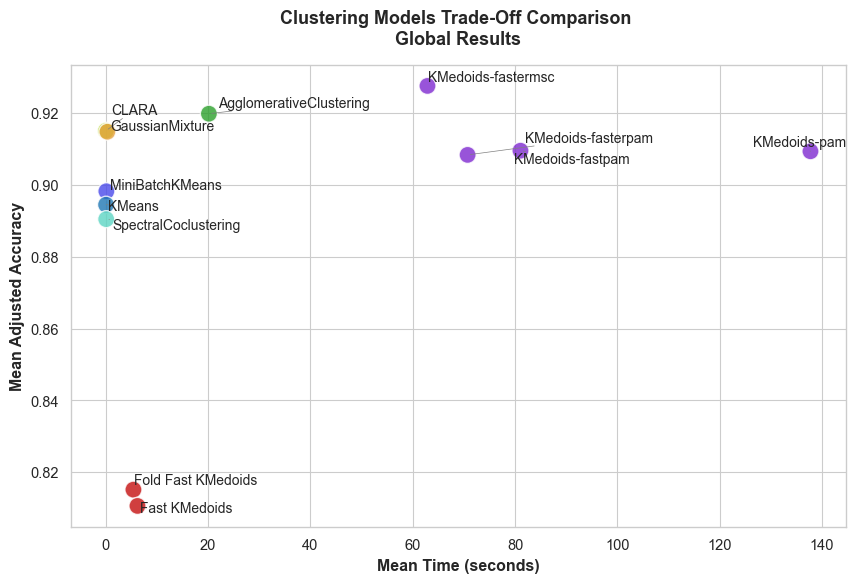

In [11]:
title = f"Clustering Models Trade-Off Comparison \nGlobal Results"

pareto_plot_experiment_5_results(
    df=df_results_master_avg['global'], 
    models_to_plot=REFERENCE_MODELS, 
    palette=REFERENCE_MODELS_PALETTE, 
    models_formatted_names=REFERENCE_MODELS_FORMATTED_NAMES,
    title=title,
    title_height=1,
    title_size=13,
    time_log_scale=False,
    show_legend=False,
    text_annotations_size=10, 
    text_annotations_y_extra_space=0,
    text_annotations_x_extra_space=0
)

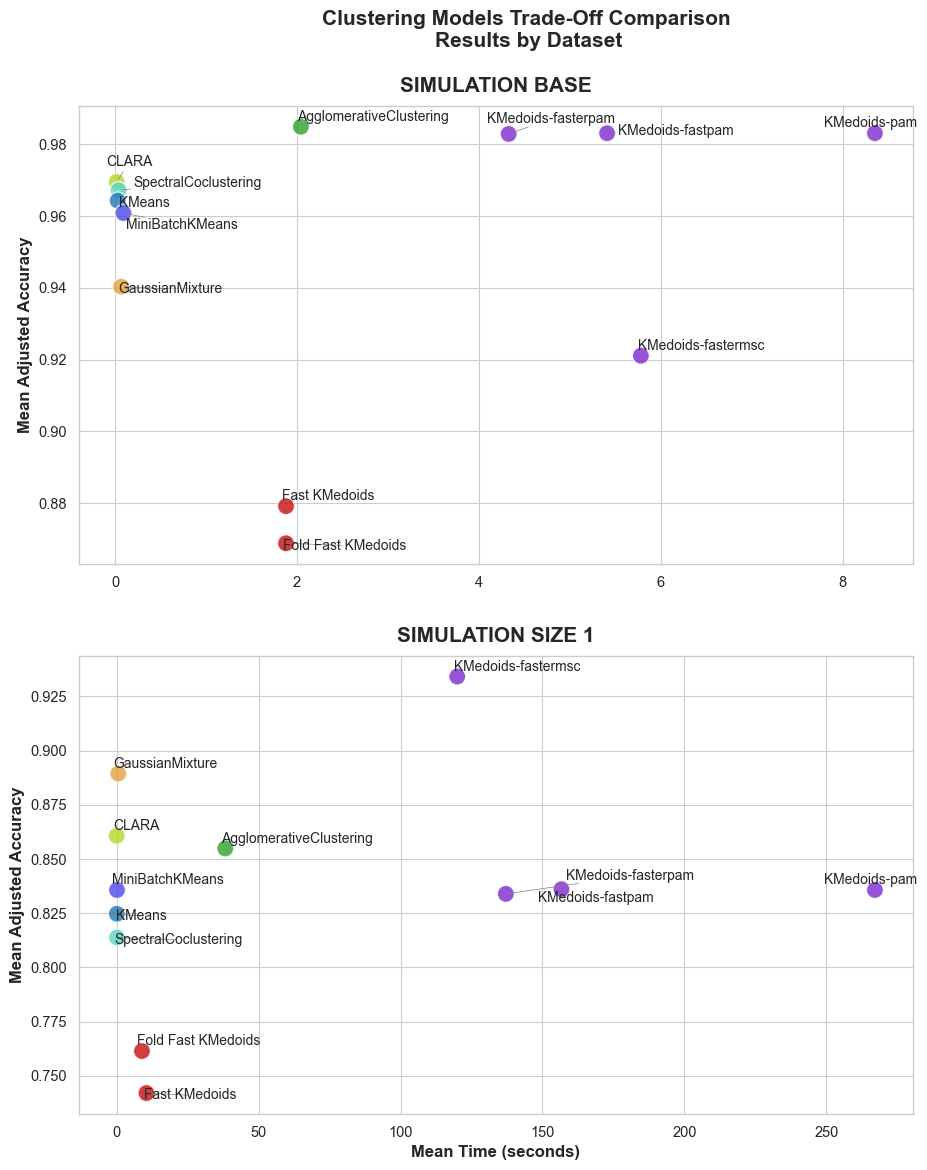

In [ ]:
datasets_to_plot = ['simulation_base', 'simulation_size_1']

title = f"Clustering Models Trade-Off Comparison \nResults by Dataset"

multi_pareto_plot_experiment_5(
    df_results_master.filter(pl.col('data_id').is_in(datasets_to_plot)), 
    subplots_col='data_id', 
    models_to_plot=REFERENCE_MODELS, 
    palette=REFERENCE_MODELS_PALETTE, 
    models_formatted_names=REFERENCE_MODELS_FORMATTED_NAMES,
    subplot_col_target_values=None, title=title, title_height=1, title_size=15,
    time_log_scale=False, save_path=None, 
    fig_height=None, fig_width=12, hspace=0.2, wspace=0.25,
    show_legend=False,
    text_annotations_size=10, 
    text_annotations_y_extra_space=0,
    text_annotations_x_extra_space=0    
)

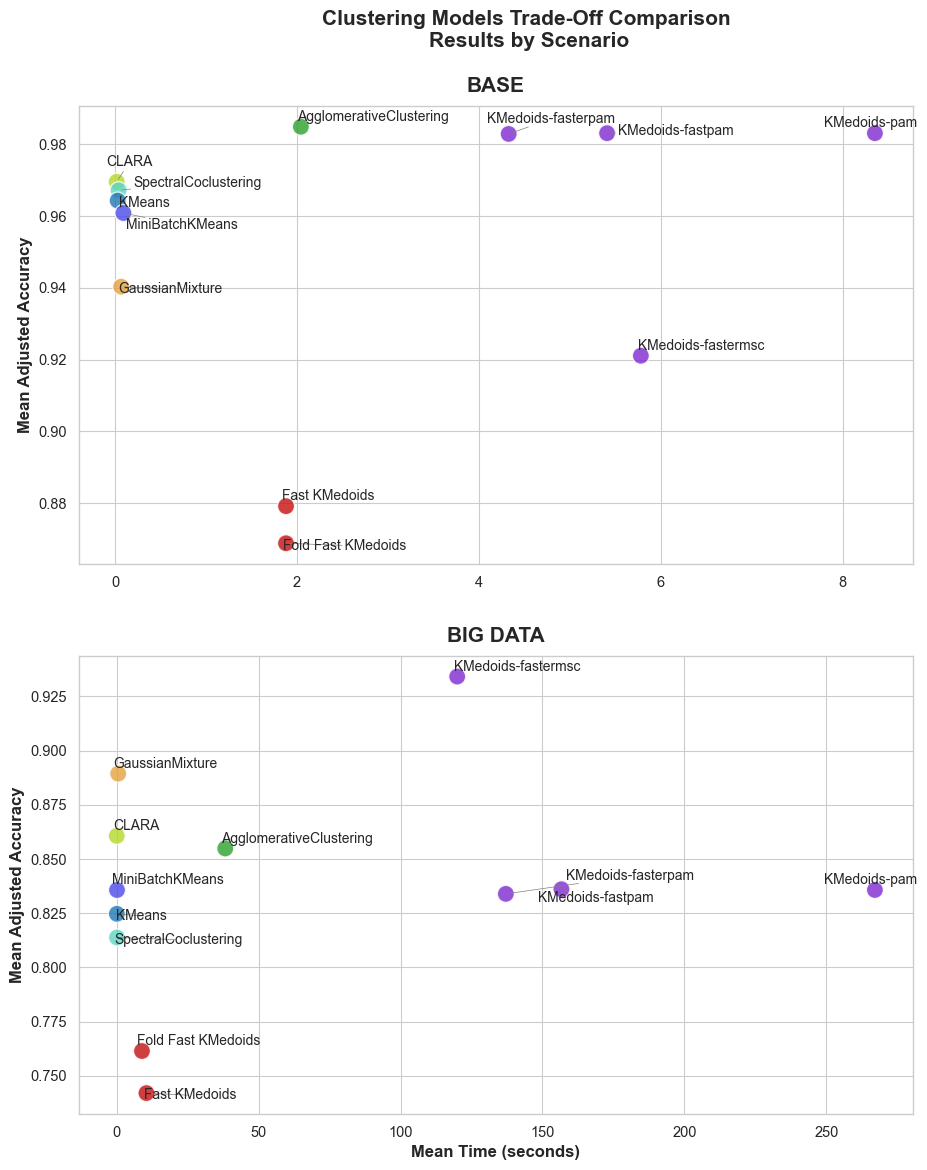

In [13]:
scenarios_to_plot = ['base', 'big_data']

title = f"Clustering Models Trade-Off Comparison \nResults by Scenario"

multi_pareto_plot_experiment_5(
    df_results_master_avg['scenario'].filter(pl.col('scenario').is_in(scenarios_to_plot)), 
    subplots_col='scenario', 
    models_to_plot=REFERENCE_MODELS, 
    palette=REFERENCE_MODELS_PALETTE, 
    models_formatted_names=REFERENCE_MODELS_FORMATTED_NAMES,
    subplot_col_target_values=None, title=title, title_height=1, title_size=15,
    time_log_scale=False, save_path=None, 
    fig_height=None, fig_width=12, hspace=0.2, wspace=0.25,
    show_legend=False,
    text_annotations_size=10, 
    text_annotations_y_extra_space=0,
    text_annotations_x_extra_space=0    
)

In [9]:
df_results_master

model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error,data_id,n_rows,n_cols,n_quant,n_binary,n_multiclass,n_clusters,separation_factor,n_redundant,cluster_proportions,anisotropy_factor,prop_categorical,mean_prop_outliers_quant,mean_prop_outliers_quant_std,outliers_contamination_type,silhouette_index,silhouette_index_std,prop_high_corr_quant,prop_high_corr_quant_std,sphericity_quant,sphericity_quant_std,prop_redundancy_quant,prop_redundancy_quant_std,normalized_balance_entropy,normalized_balance_entropy_std,imbalance_ratio,imbalance_ratio_std,is_balanced,convex_geometry,scenario
str,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,f64,i64,list[f64],f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,str
"""LDAKmeans""",0.975707,0.991565,0.143658,0.037693,0.013565,0.073862,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""AgglomerativeClustering""",0.958265,0.984872,2.042846,0.06321,0.024657,0.133425,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""Birch""",0.95491,0.983702,2.022754,0.065081,0.024804,0.228396,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""KMedoids-fastpam""",0.952461,0.983078,5.407941,0.058846,0.022114,0.75391,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
"""KMedoids-pam""",0.952461,0.983078,8.351408,0.058846,0.022114,1.638773,0.0,"""simulation_base""",10000,8,4,2,2,3,1.0,0,"[0.3334, 0.3333, 0.3333]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5236,0.1028,0.2967,0.2063,0.9993,0.0002,0.3625,0.134,1.0,0.0,1.0003,0.0,true,true,"""base"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""FastKmedoidsGGower-robust_maha…",0.62631,0.742237,10.513761,0.133022,0.067519,3.904162,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""
"""FastKmedoidsGGower-robust_maha…",0.625449,0.742065,10.512631,0.132632,0.066695,3.821116,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""
"""FastKmedoidsGGower-robust_maha…",0.585553,0.727289,9.847082,0.152168,0.082899,4.14243,0.0,"""simulation_size_1""",35000,8,4,2,2,3,1.0,0,"[0.333343, 0.333343, 0.333314]",1.0,0.5,0.0022,0.0022,"""not_contaminated""",0.5239,0.1027,0.2967,0.2063,0.9998,0.0001,0.36,0.1338,1.0,0.0,1.0001,0.0,true,true,"""big_data"""


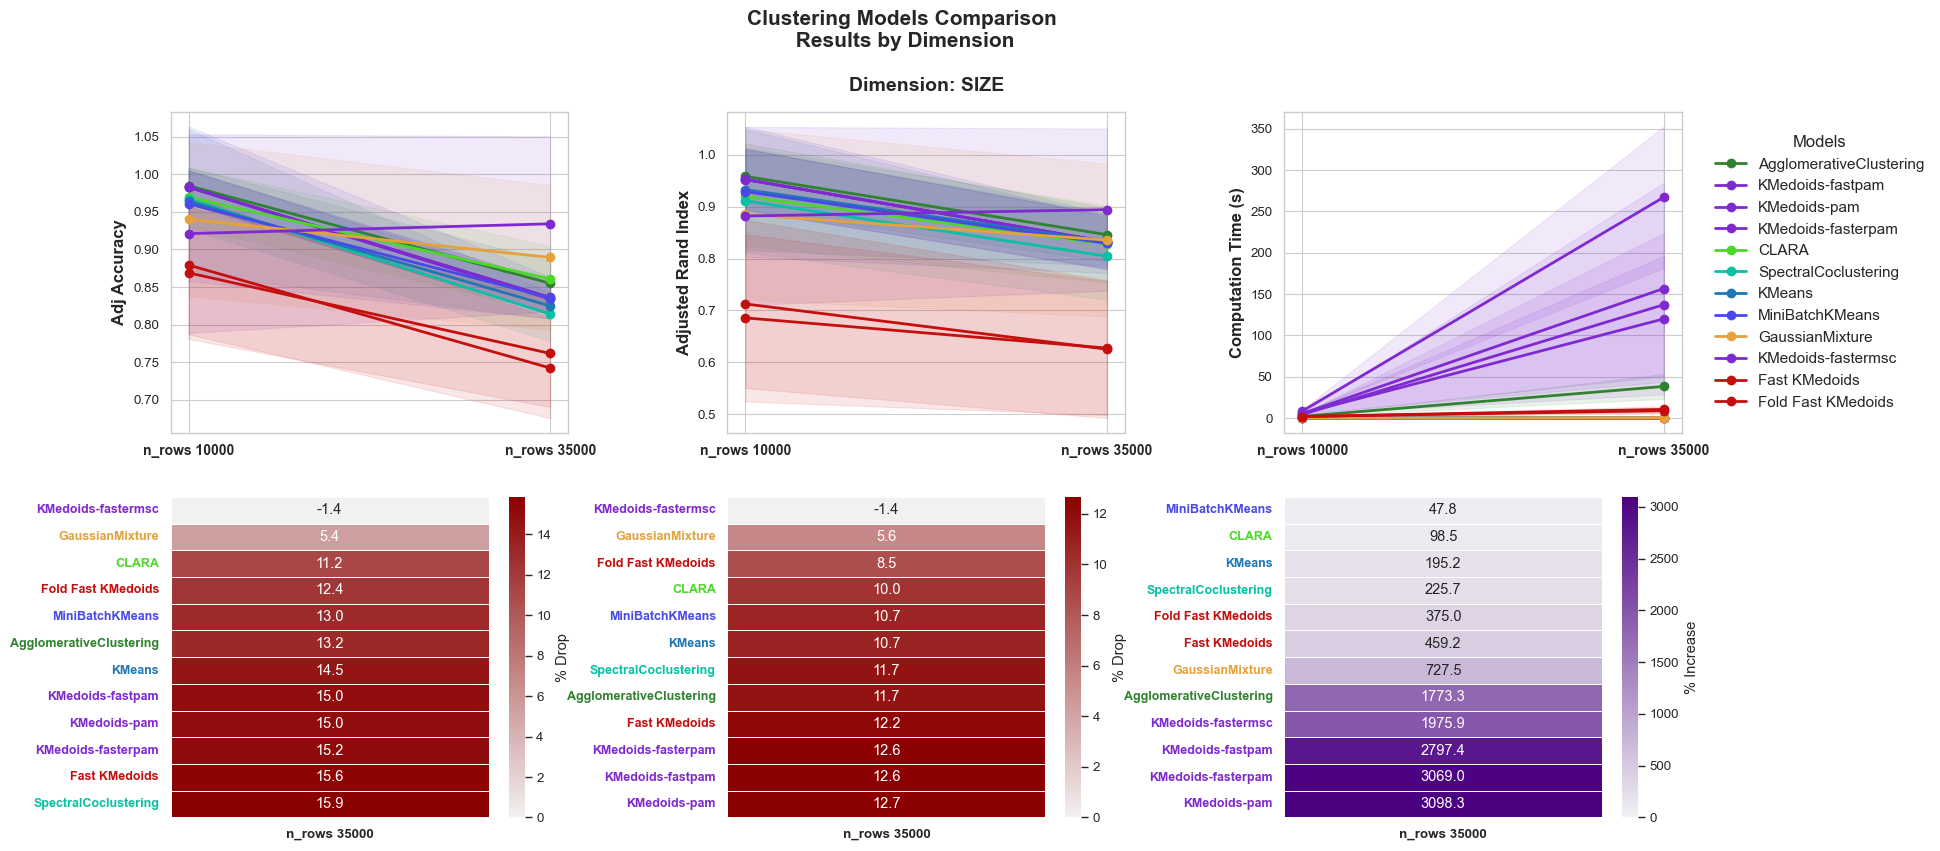

In [ ]:
dimensions_to_plot = ['size']
dimensions_filtered = {k: v for k, v in DIMENSIONS.items() if k in dimensions_to_plot}

title = "Clustering Models Comparison\n Results by Dimension"

dimensions_plot_experiment_5(
    df=df_results_master.filter(pl.col('dimension').is_in(dimensions_to_plot)), 
    dimensions_dict=dimensions_filtered, 
    dimensions_formatted=DIMENSIONS_FORMATTED,
    models_to_plot=REFERENCE_MODELS,  
    palette=REFERENCE_MODELS_PALETTE, 
    models_formatted_names=REFERENCE_MODELS_FORMATTED_NAMES,
    time_log_scale=False,
    title=title,
    title_height=1,
    wspace=0.4,
    hspace=0.2,
    save_path=None 
)


In [4]:
REFERENCE_MODELS_2 = [
    'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming', # TODO: escoger el mejor a nivel global, por dataset, por escenario, por dimensión --> si hay mucha diferencia podría implicar que REFERENCE_MODELS fuese un diccionario en función del nivel analizado
    'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming', # TODO: escoger el mejor a nivel global, por dataset, por escenario, por dimensión --> si hay mucha diferencia podría implicar que REFERENCE_MODELS fuese un diccionario en función del nivel analizado
    'KMeans',
    'MiniBatchKMeans',
    'KMedoids-pam',
    'KMedoids-fastpam',
    'KMedoids-fasterpam',
    'KMedoids-fastermsc',
    'CLARA'
]

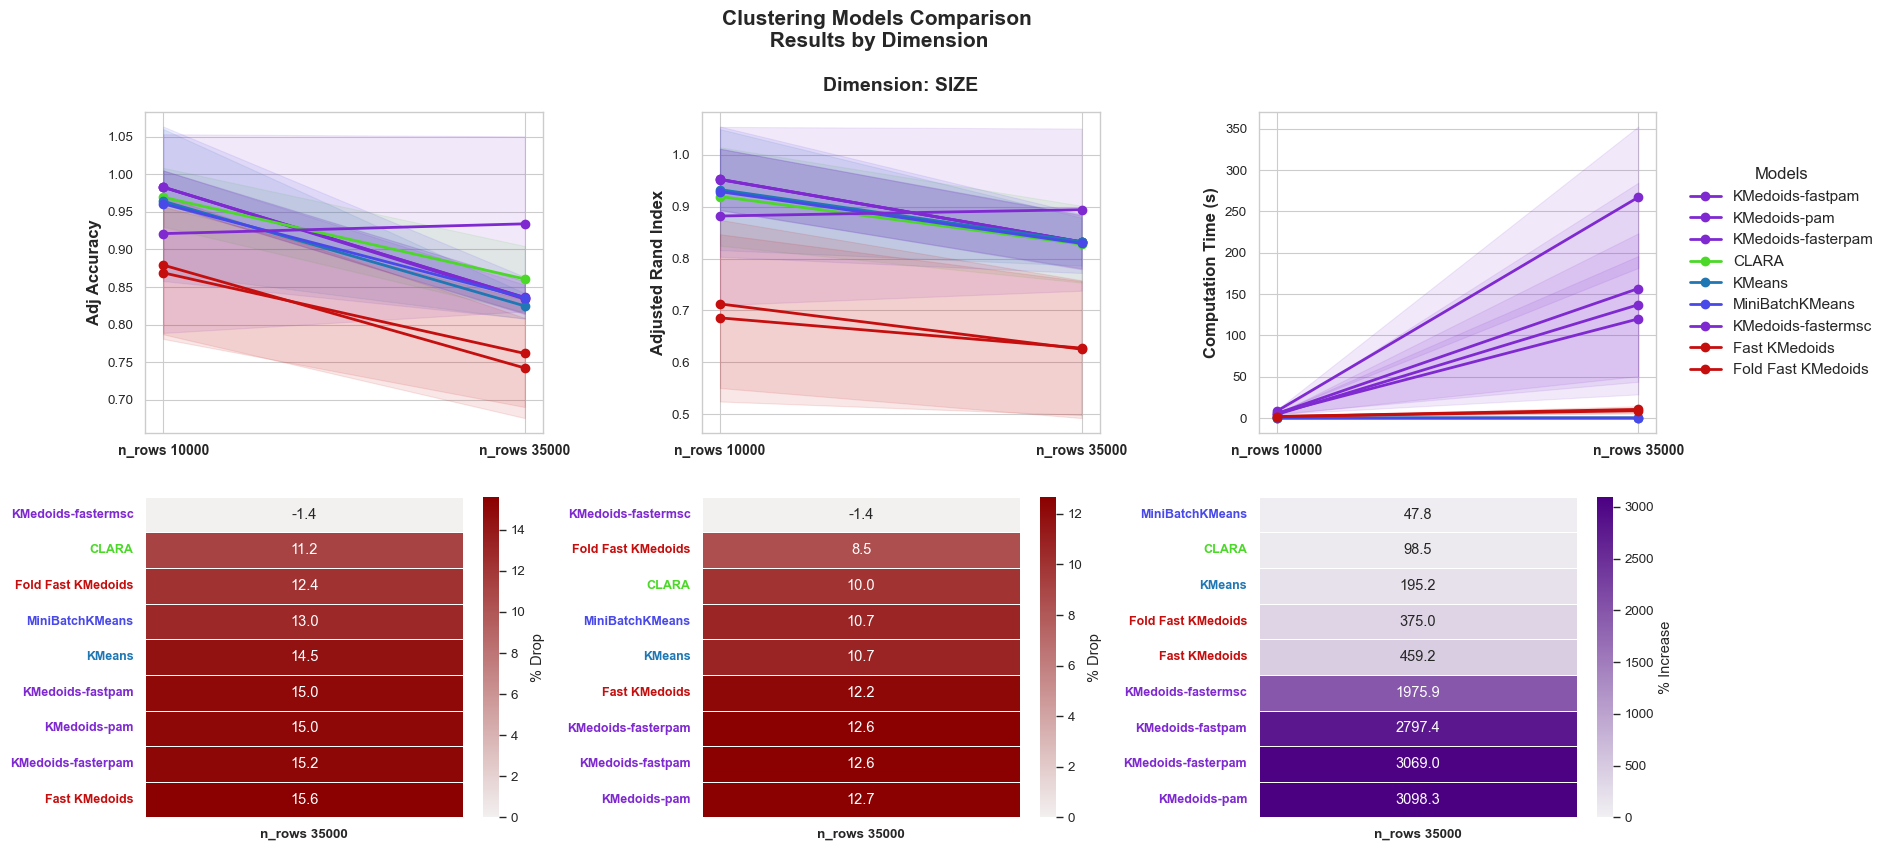

In [ ]:
dimensions_to_plot = ['size']
dimensions_filtered = {k: v for k, v in DIMENSIONS.items() if k in dimensions_to_plot}

title = "Clustering Models Comparison\n Results by Dimension"

dimensions_plot_experiment_5(
    df=df_results_master, 
    dimensions_dict=DIMENSIONS, 
    dimensions_formatted=DIMENSIONS_FORMATTED,
    models_to_plot=REFERENCE_MODELS_2,  
    palette=REFERENCE_MODELS_PALETTE, 
    models_formatted_names=REFERENCE_MODELS_FORMATTED_NAMES,
    time_log_scale=False,
    title=title,
    title_height=1,
    wspace=0.4,
    hspace=0.2,
    save_path=None 
)
